<h1 align="center">Machine Learning Fundamentals</h1> 

## Data loading and exploration

### Imports

In [62]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

### Q1: Load the Iris dataset using sklearn.datasets.load_iris() and print feature_names , target_names , and the shape of data .

In [5]:
iris = sk.datasets.load_iris()

In [6]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [11]:
iris["data"].shape

(150, 4)

### Q2: Provide a short written answer: What type of problem is this classification/regression)? Why? Write your answer in a Markdown cell below.

This is an example of a classification problem. The possible outputs are classes of iris flower (target_names).

### Q3: Show the first five rows of the data as a pandas DataFrame with column names from feature_names

In [17]:
iris_df = pd.DataFrame(iris["data"], columns=iris["feature_names"])

In [18]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Q4: Report class distribution (counts for each species)

In [21]:
iris_classes = pd.Series(iris["target"], name="target")

In [22]:
iris_classes

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [24]:
iris_classes.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

## Visualization

### Q5. Create a pair plot (scatter plot matrix) for the four features using matplotlib. Color points by species.

In [ ]:
colors = {}

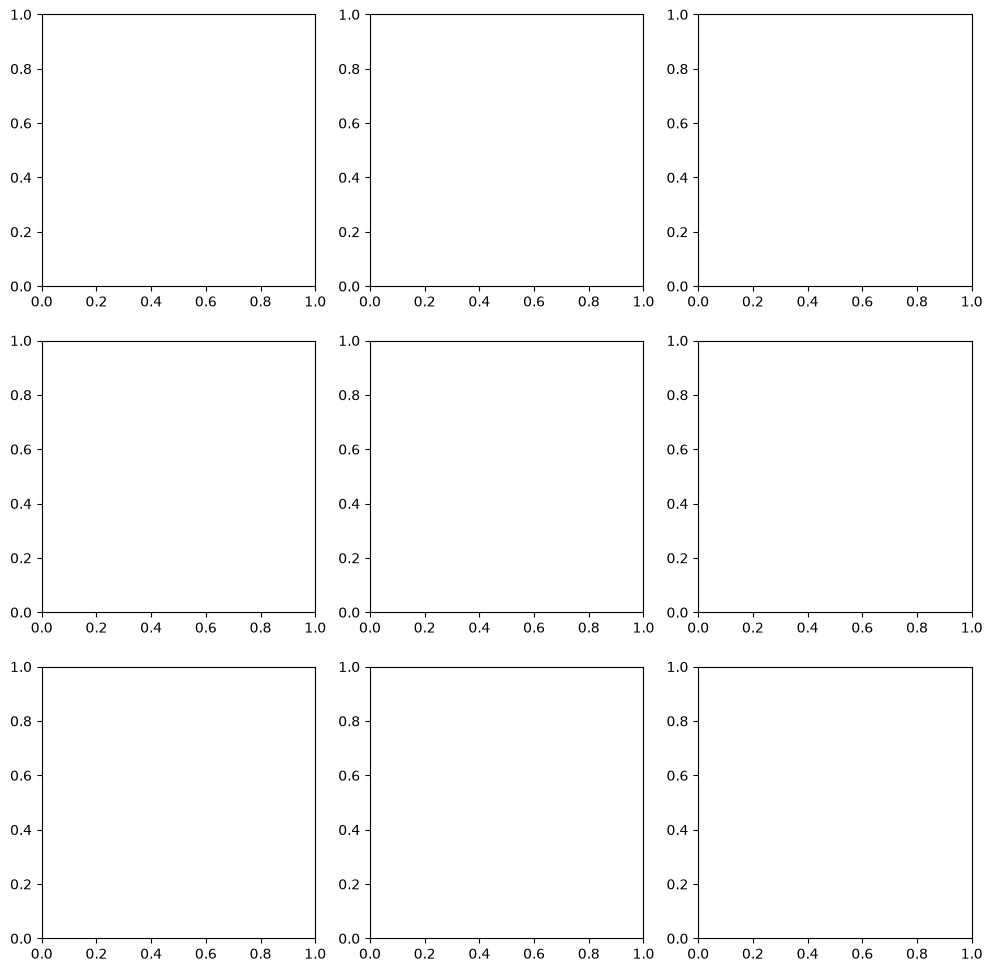

In [44]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12)) 

In [45]:
x = iris["data"]
y = iris["target"]
for i in range(3):
    for j in range(3):
        ax[i, j].scatter(x[:, j], x[:, i + 1], c=y, s=60)
        ax[i, j].set_xticks(())
        ax[i, j].set_yticks(())
        if i == 2:
            ax[i, j].set_xlabel(iris['feature_names'][j])
        if j == 0:
            ax[i, j].set_ylabel(iris['feature_names'][i + 1])
        if j > i:
            ax[i, j].set_visible(False)

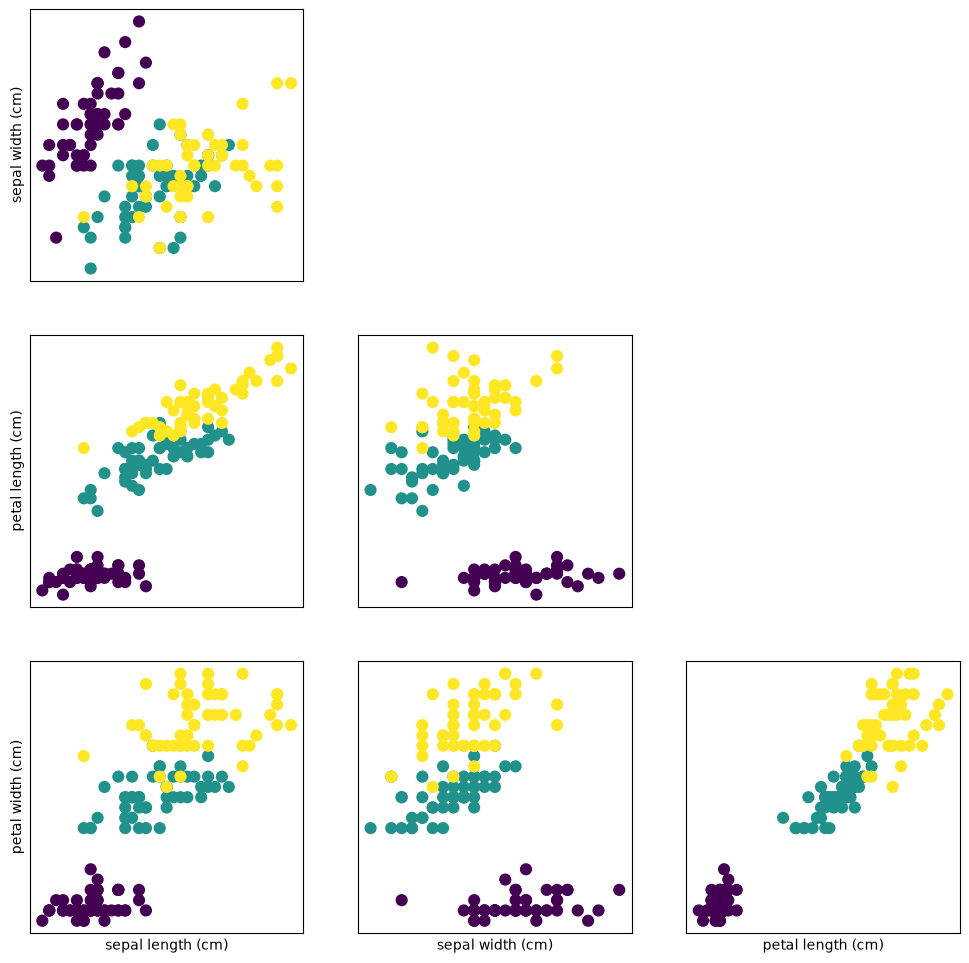

In [46]:
fig

### Q6: Based on your plot, which two features appear most useful to separate the classes? Explain in one short sentence.

From the plots, we can see that the three classes seem to be relatively well separated using
the sepal and petal measurements. The petal length and petal width features show the most difference between points.

## Train - Test - split and KNN modeling

### Q7: Split the data into train/test sets (75% train, 25% test). Use stratify=target and random_state=42 . Print shapes.

In [50]:
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(
    iris['data'], 
    iris['target'], 
    random_state=42, 
    stratify = iris['target']
)

In [55]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(112, 4)
(38, 4)
(112,)
(38,)


### Q8: Train a KNeighborsClassifier with n_neighbors=3 . Fit on training data and report test accuracy.

In [64]:
knn = sk.neighbors.KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [77]:
y_pred = knn.predict(x_test)
np.mean(y_pred == y_test)

np.float64(0.9736842105263158)

### Q9. Compare accuracy for n_neighbors = 1, 3, 5. Report which k gives best accuracy and why (short sentence).

In [80]:
knn1 = sk.neighbors.KNeighborsClassifier(n_neighbors=1)
knn1.fit(x_train, y_train)
knn5 = sk.neighbors.KNeighborsClassifier(n_neighbors=5)
knn5.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [81]:
y_pred_1 = knn1.predict(x_test)
y_pred_5 = knn5.predict(x_test)

In [86]:
print(np.mean(y_pred_1 == y_test))
print(np.mean(y_pred == y_test))
print(np.mean(y_pred_5 == y_test))
print(knn.score(x_test, y_test))

0.9473684210526315
0.9736842105263158
0.9736842105263158
0.9736842105263158


## Prediction

### Q10: Use your trained KNeighborsClassifier (use k=3) to predict the class of a new sample with features: [5.0, 2.9, 1.0, 0.2] . Show predicted class name.

In [73]:
x_new = np.array([[5, 2.9, 1, 0.2]])

In [74]:
prediction = knn.predict(x_new)
iris["target_names"][prediction]

array(['setosa'], dtype='<U10')